# RSFAKE Analysis

Reproducible pipeline for the main RSFAKE experiments using the balanced 8,000-image subset.


## 0. Imports


In [2]:
from google.colab import drive

import cv2
import json
import os
import random
import re
import shutil
import warnings
import zipfile
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit


## 0.1 Environment and reproducibility


In [3]:
drive.mount('/content/drive')

warnings.filterwarnings('ignore')

SEED = 42
SCENES = ['water', 'agriculture', 'urban', 'transport', 'industrial']
B = 2000

DRIVE = '/content/drive/MyDrive'
OUT = f'{DRIVE}/rsfake_clean_rerun'
os.makedirs(OUT, exist_ok=True)


def seed_everything(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass


seed_everything()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
print('output folder:', OUT)


Mounted at /content/drive
device: cuda
output folder: /content/drive/MyDrive/rsfake_clean_rerun


## 1. Restore images and load RemoteCLIP labels


In [6]:
for name, zf in [('real', 'real_images_final.zip'), ('fake_new', 'fake_new_backup.zip')]:
    tgt = f'/content/data/{name}'

    if not os.path.exists(tgt) or len(os.listdir(tgt)) == 0:
        os.makedirs(tgt, exist_ok=True)
        local_zip = f'/content/{zf}'
        shutil.copy(f'{DRIVE}/{zf}', local_zip)

        with zipfile.ZipFile(local_zip) as z:
            z.extractall(tgt)

        os.remove(local_zip)
        print('restored', name)

CACHE = f'{DRIVE}/remoteclip_labels_10gen.csv'
df = pd.read_csv(CACHE)
df['label_id'] = (df['label'] == 'fake').astype(int)
df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

print('usable rows:', len(df))
print(df.groupby(['clip_scene', 'label']).size().unstack(fill_value=0))


restored real
restored fake_new
usable rows: 39979
label        fake  real
clip_scene             
agriculture  5257  3168
industrial   3984  6968
transport    1591  1049
urban        5511  5636
water        3657  3158


## 2. Source-location IDs

fMoW instance IDs are used to keep observations from the same source location in one group.


In [7]:
def _stem(path):
    s = os.path.basename(path)
    s = re.sub(r'\.(jpg|jpeg|png)$', '', s, flags=re.I)
    s = re.sub(r'_(msrgb|rgb)$', '', s, flags=re.I)
    s = re.sub(r'^patch_', '', s, flags=re.I)
    return s


def old_location_id(path):
    s = _stem(path)
    m = re.match(r'^(.+_\d+)_\d+$', s)
    return m.group(1) if m else s


def fmow_location_id(path):
    s = _stem(path)
    # category_instance_observation[_patch...] -> category_instance
    m = re.match(r'^(.+?_\d+)(?:_\d+)+$', s)
    return m.group(1) if m else s


def gen_from_name(path):
    f = os.path.basename(path)
    return f.split('__')[0] if '__' in f else None


real_mask = df['label_id'].eq(0)
df['old_location'] = df['path'].apply(old_location_id)
df['location'] = df['path'].apply(fmow_location_id)
df['generator'] = np.where(
    df['label_id'].eq(1),
    df['path'].apply(gen_from_name),
    'real',
)

print('real images:', int(real_mask.sum()))
print(
    'old parser unique locations:',
    df.loc[real_mask, 'old_location'].nunique(),
)
print(
    'canonical parser unique locations:',
    df.loc[real_mask, 'location'].nunique(),
)
print(
    'average patches/location:',
    round(
        real_mask.sum()
        / df.loc[real_mask, 'location'].nunique(),
        3,
    ),
)

changed = df.loc[
    real_mask & df['old_location'].ne(df['location']),
    ['path', 'old_location', 'location'],
]
print('rows whose grouping changed:', len(changed))
display(changed.head(20))

# Show the most repeated canonical locations as a sanity check.
display(
    df.loc[real_mask, 'location']
    .value_counts()
    .head(15)
    .rename('n_patches')
    .to_frame()
)


real images: 19979
old parser unique locations: 15861
canonical parser unique locations: 15861
average patches/location: 1.26
rows whose grouping changed: 0


,path,old_location,location


,n_patches
location,
barn_2106,10
lake_or_pond_89,10
lake_or_pond_20,9
barn_2003,8
aquaculture_380,8
barn_109,8
barn_1937,7
lake_or_pond_111,7
lake_or_pond_133,7


## 3. Balanced dataset and main split


In [ ]:
seed_everything()

PER = 800
parts = []

for sc in SCENES:
    for lab in [0, 1]:
        cell = df[
            (df.clip_scene == sc)
            & (df.label_id == lab)
        ]

        if len(cell) < PER:
            raise ValueError(
                f'Not enough images for {sc}, label={lab}: {len(cell)}'
            )

        parts.append(
            cell.sample(
                n=PER,
                random_state=SEED,
            )
        )

bal = pd.concat(parts).reset_index(drop=True)
bal['sample_id'] = np.arange(len(bal))
bal['group'] = np.where(
    bal['label_id'].eq(0),
    bal['location'],
    'fake_' + bal['sample_id'].astype(str),
)

print('balanced size:', len(bal))
print(
    bal.groupby(['clip_scene', 'label_id'])
    .size()
    .unstack(fill_value=0)
)

print('\nfake scene x generator composition:')
display(
    bal[bal.label_id.eq(1)]
    .groupby(['clip_scene', 'generator'])
    .size()
    .unstack(fill_value=0)
)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED,
)
i_tr, i_te = next(
    gss.split(
        bal,
        groups=bal['group'],
    )
)

bal['split'] = 'train'
bal.loc[i_te, 'split'] = 'test'

train_df = bal[bal.split.eq('train')].copy()
test_df = bal[bal.split.eq('test')].copy()

leak = (
    set(
        train_df.loc[
            train_df.label_id.eq(0),
            'location',
        ]
    )
    & set(
        test_df.loc[
            test_df.label_id.eq(0),
            'location',
        ]
    )
)

print(
    'train:',
    len(train_df),
    'test:',
    len(test_df),
    'real-location leakage:',
    len(leak),
)

print('\ntest composition:')
display(
    test_df.groupby(['clip_scene', 'label_id'])
    .size()
    .unstack(fill_value=0)
)

manifest_path = f'{OUT}/rsfake_balanced_manifest_seed42.csv'
bal.to_csv(manifest_path, index=False)
print('saved:', manifest_path)


balanced size: 8000
label_id       0    1
clip_scene           
agriculture  800  800
industrial   800  800
transport    800  800
urban        800  800
water        800  800

fake scene x generator composition:


generator,crsdiff,diffusionsat_256,diffusionsat_512,georssd,geosynth_canny,geosynth_sam,geosynth_text,mapsat,rsinpaint,sdfrs
clip_scene,,,,,,,,,,
agriculture,46,46,23,99,119,102,65,168,61,71
industrial,73,117,137,42,71,75,88,16,72,109
transport,54,54,38,112,69,138,142,14,89,90
urban,142,113,105,48,55,47,79,72,82,57
water,39,115,72,63,89,101,55,80,88,98


train: 6392 test: 1608 real-location leakage: 0

test composition:


label_id,0,1
clip_scene,,
agriculture,179,155
industrial,153,160
transport,173,152
urban,141,147
water,184,164


saved: /content/drive/MyDrive/rsfake_clean_rerun/rsfake_balanced_manifest_seed42.csv


## 4. Preprocessing and training functions


In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)


class RSFakeDS(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        r = self.frame.iloc[i]
        x = transform(
            Image.open(r['path']).convert('RGB')
        )
        return (
            x,
            int(r['label_id']),
            r['clip_scene'],
            r['group'],
            r['path'],
        )


def loader(
    frame,
    shuffle=False,
    seed=SEED,
    batch_size=32,
):
    g = torch.Generator()
    g.manual_seed(seed)

    return DataLoader(
        RSFakeDS(frame),
        batch_size=batch_size,
        shuffle=shuffle,
        generator=g,
        num_workers=0,
    )


def make_resnet(seed=SEED):
    seed_everything(seed)

    m = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V2
    )

    for p in m.parameters():
        p.requires_grad = False

    m.fc = nn.Linear(
        m.fc.in_features,
        2,
    )

    return m.to(device)


def make_vit(seed=SEED):
    seed_everything(seed)

    m = models.vit_b_16(
        weights=models.ViT_B_16_Weights.IMAGENET1K_V1
    )

    for p in m.parameters():
        p.requires_grad = False

    m.heads.head = nn.Linear(
        m.heads.head.in_features,
        2,
    )

    return m.to(device)


def train_model(
    model,
    frame,
    epochs=5,
    lr=1e-3,
    seed=SEED,
):
    seed_everything(seed)

    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(
        (
            p
            for p in model.parameters()
            if p.requires_grad
        ),
        lr=lr,
    )
    ld = loader(
        frame,
        shuffle=True,
        seed=seed,
    )

    for e in range(epochs):
        model.train()
        run = 0.0

        for x, y, _, _, _ in ld:
            x, y = x.to(device), y.to(device)

            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()

            run += loss.item()

        print(
            f'epoch {e + 1}/{epochs} '
            f'loss {run / len(ld):.4f}'
        )

    return model


def predict(model, frame):
    model.eval()
    rows = []

    with torch.no_grad():
        for x, y, sc, grp, path in loader(
            frame,
            shuffle=False,
        ):
            prob = (
                torch.softmax(
                    model(x.to(device)),
                    1,
                )[:, 1]
                .cpu()
                .numpy()
            )

            for i in range(len(y)):
                rows.append(
                    {
                        'path': path[i],
                        'label': int(y[i]),
                        'scene': sc[i],
                        'group': grp[i],
                        'prob_fake': float(prob[i]),
                    }
                )

    out = pd.DataFrame(rows)
    out['pred'] = (
        out.prob_fake >= 0.5
    ).astype(int)

    return out


## 5. Main ResNet-50 experiment


In [ ]:
seed_everything()

resnet = make_resnet(SEED)
resnet = train_model(
    resnet,
    train_df,
    epochs=5,
    lr=1e-3,
    seed=SEED,
)

ckpt_path = f'{OUT}/resnet50_main_seed42.pt'
torch.save(
    {
        'state_dict': resnet.state_dict(),
        'seed': SEED,
        'input_size': 224,
        'mean': IMAGENET_MEAN,
        'std': IMAGENET_STD,
        'manifest': manifest_path,
    },
    ckpt_path,
)
print('saved checkpoint:', ckpt_path)

pred = predict(resnet, test_df)
pred_path = f'{OUT}/resnet50_main_test_predictions.csv'
pred.to_csv(pred_path, index=False)
print('saved predictions:', pred_path)

print('\nMAIN OVERALL')
print(
    'accuracy = {:.3f} ({:.1f}%)'.format(
        accuracy_score(pred.label, pred.pred),
        100 * accuracy_score(pred.label, pred.pred),
    )
)
print(
    'AUC      = {:.6f}'.format(
        roc_auc_score(pred.label, pred.prob_fake)
    )
)
print(
    'confusion [[TN,FP],[FN,TP]] =',
    confusion_matrix(pred.label, pred.pred).tolist(),
)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


epoch 1/5 loss 0.3911
epoch 2/5 loss 0.2760
epoch 3/5 loss 0.2402
epoch 4/5 loss 0.2149
epoch 5/5 loss 0.2000
saved checkpoint: /content/drive/MyDrive/rsfake_clean_rerun/resnet50_main_seed42.pt
saved predictions: /content/drive/MyDrive/rsfake_clean_rerun/resnet50_main_test_predictions.csv

MAIN OVERALL
accuracy = 0.921 (92.1%)
AUC      = 0.976114
confusion [[TN,FP],[FN,TP]] = [[782, 48], [79, 699]]


## 6. Bootstrap confidence intervals and pairwise AUC


In [ ]:
def auc_ci(labels, probs, B=B, seed=SEED):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    idx = np.arange(len(labels))

    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(B):
        s = rng.choice(
            idx,
            len(idx),
            replace=True,
        )

        if np.unique(labels[s]).size < 2:
            continue

        vals.append(
            roc_auc_score(
                labels[s],
                probs[s],
            )
        )

    vals = np.asarray(vals)

    return (
        roc_auc_score(labels, probs),
        np.percentile(vals, 2.5),
        np.percentile(vals, 97.5),
    )


def pair_auc_diff(a, b, B=B, seed=SEED):
    la, pa = (
        a.label.to_numpy(),
        a.prob_fake.to_numpy(),
    )
    lb, pb = (
        b.label.to_numpy(),
        b.prob_fake.to_numpy(),
    )

    ia, ib = np.arange(len(a)), np.arange(len(b))
    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(B):
        sa = rng.choice(
            ia,
            len(ia),
            True,
        )
        sb = rng.choice(
            ib,
            len(ib),
            True,
        )

        if (
            np.unique(la[sa]).size < 2
            or np.unique(lb[sb]).size < 2
        ):
            continue

        vals.append(
            roc_auc_score(la[sa], pa[sa])
            - roc_auc_score(lb[sb], pb[sb])
        )

    vals = np.asarray(vals)
    point = (
        roc_auc_score(la, pa)
        - roc_auc_score(lb, pb)
    )

    return (
        point,
        np.percentile(vals, 2.5),
        np.percentile(vals, 97.5),
    )


rows = []

for i, sc in enumerate(SCENES):
    d = pred[pred.scene.eq(sc)]

    auc, lo, hi = auc_ci(
        d.label,
        d.prob_fake,
        seed=SEED + 100 + i,
    )

    rows.append(
        {
            'scene': sc,
            'AUC': auc,
            'CI_low': lo,
            'CI_high': hi,
            'n_test': len(d),
        }
    )

table41 = pd.DataFrame(rows)
display(table41)

table41.to_csv(
    f'{OUT}/table4_1_per_scene_auc.csv',
    index=False,
)

pairs = []

for k, (a, b) in enumerate(
    combinations(SCENES, 2)
):
    point, lo, hi = pair_auc_diff(
        pred[pred.scene.eq(a)],
        pred[pred.scene.eq(b)],
        seed=SEED + 200 + k,
    )

    pairs.append(
        {
            'scene_pair': f'{a} - {b}',
            'delta_AUC': point,
            'CI_low': lo,
            'CI_high': hi,
            'includes_zero': lo <= 0 <= hi,
        }
    )

pair_df = pd.DataFrame(pairs)
display(pair_df)

pair_df.to_csv(
    f'{OUT}/table4_2_pairwise_auc.csv',
    index=False,
)


,scene,AUC,CI_low,CI_high,n_test
0,water,0.969777,0.954410,0.981980,348
1,agriculture,0.984394,0.972340,0.993194,334
2,urban,0.987938,0.978759,0.994879,288
3,transport,0.972848,0.953657,0.988544,325
4,industrial,0.972467,0.957338,0.984887,313


,scene_pair,delta_AUC,CI_low,CI_high,includes_zero
0,water - agriculture,-0.014616,-0.032559,0.002757,True
1,water - urban,-0.018161,-0.034795,-0.002120,False
2,water - transport,-0.003070,-0.025757,0.020263,True
3,water - industrial,-0.002690,-0.023291,0.017126,True
4,agriculture - urban,-0.003545,-0.017384,0.009251,True
5,agriculture - transport,0.011546,-0.007538,0.033967,True
6,agriculture - industrial,0.011926,-0.004939,0.031332,True
7,urban - transport,0.015091,-0.002892,0.036365,True
8,urban - industrial,0.015471,-0.000162,0.032424,True
9,transport - industrial,0.000380,-0.022532,0.023179,True


## 7. Per-scene error analysis


In [ ]:
rows = []

for sc in SCENES:
    d = pred[pred.scene.eq(sc)]

    tn, fp, fn, tp = confusion_matrix(
        d.label,
        d.pred,
        labels=[0, 1],
    ).ravel()

    rows.append(
        {
            'scene': sc,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'FN_rate': fn / (fn + tp),
            'FP_rate': fp / (fp + tn),
        }
    )

err = pd.DataFrame(rows)
display(err)

err.to_csv(
    f'{OUT}/table4_3_error_breakdown.csv',
    index=False,
)

print(
    'check overall from table:',
    (err.TN.sum() + err.TP.sum())
    / err[['TN', 'FP', 'FN', 'TP']]
    .sum()
    .sum(),
)


,scene,TN,FP,FN,TP,FN_rate,FP_rate
0,water,165,19,20,144,0.121951,0.103261
1,agriculture,169,10,7,148,0.045161,0.055866
2,urban,129,12,9,138,0.061224,0.085106
3,transport,168,5,14,138,0.092105,0.028902
4,industrial,151,2,29,131,0.181250,0.013072


check overall from table: 0.9210199004975125


## 8. Source-location cluster bootstrap


In [ ]:
def cluster_auc_ci(d, B=B, seed=SEED):
    groups = d.group.to_numpy(dtype=object)
    labels = d.label.to_numpy()
    probs = d.prob_fake.to_numpy()

    uniq = np.unique(groups)
    members = {
        g: np.where(groups == g)[0]
        for g in uniq
    }

    rng = np.random.default_rng(seed)
    vals = []

    for _ in range(B):
        sampled = rng.choice(
            uniq,
            len(uniq),
            replace=True,
        )
        idx = np.concatenate(
            [members[g] for g in sampled]
        )

        if np.unique(labels[idx]).size < 2:
            continue

        vals.append(
            roc_auc_score(
                labels[idx],
                probs[idx],
            )
        )

    vals = np.asarray(vals)

    return (
        roc_auc_score(labels, probs),
        np.percentile(vals, 2.5),
        np.percentile(vals, 97.5),
    )


cluster_rows = []

for i, sc in enumerate(SCENES):
    d = pred[pred.scene.eq(sc)].copy()

    auc, lo, hi = cluster_auc_ci(
        d,
        seed=SEED + 300 + i,
    )

    cluster_rows.append(
        {
            'scene': sc,
            'AUC': auc,
            'cluster_CI_low': lo,
            'cluster_CI_high': hi,
            'n_images': len(d),
            'n_groups': d.group.nunique(),
        }
    )

cluster_df = pd.DataFrame(cluster_rows)
display(cluster_df)

cluster_df.to_csv(
    f'{OUT}/cluster_bootstrap.csv',
    index=False,
)


,scene,AUC,cluster_CI_low,cluster_CI_high,n_images,n_groups
0,water,0.969777,0.953955,0.982442,348,329
1,agriculture,0.984394,0.973214,0.993253,334,325
2,urban,0.987938,0.979207,0.995081,288,286
3,transport,0.972848,0.953193,0.988488,325,315
4,industrial,0.972467,0.957613,0.984980,313,311


## 9. ViT-B/16 robustness check


In [ ]:
seed_everything()

vit = make_vit(SEED)
vit = train_model(
    vit,
    train_df,
    epochs=5,
    lr=1e-3,
    seed=SEED,
)

vit_pred = predict(vit, test_df)

vit_pred.to_csv(
    f'{OUT}/vit_main_test_predictions.csv',
    index=False,
)

print(
    'ViT accuracy:',
    accuracy_score(
        vit_pred.label,
        vit_pred.pred,
    ),
)
print(
    'ViT AUC:',
    roc_auc_score(
        vit_pred.label,
        vit_pred.prob_fake,
    ),
)

vit_rows = []

for i, sc in enumerate(SCENES):
    d = vit_pred[vit_pred.scene.eq(sc)]

    auc, lo, hi = auc_ci(
        d.label,
        d.prob_fake,
        seed=SEED + 400 + i,
    )

    vit_rows.append(
        {
            'scene': sc,
            'AUC': auc,
            'CI_low': lo,
            'CI_high': hi,
        }
    )

vit_table = pd.DataFrame(vit_rows)
display(vit_table)

vit_table.to_csv(
    f'{OUT}/table4_5_vit_per_scene.csv',
    index=False,
)

vit_pairs = []

for k, (a, b) in enumerate(
    combinations(SCENES, 2)
):
    point, lo, hi = pair_auc_diff(
        vit_pred[vit_pred.scene.eq(a)],
        vit_pred[vit_pred.scene.eq(b)],
        seed=SEED + 500 + k,
    )

    vit_pairs.append(
        {
            'scene_pair': f'{a} - {b}',
            'delta_AUC': point,
            'CI_low': lo,
            'CI_high': hi,
            'includes_zero': lo <= 0 <= hi,
        }
    )

display(pd.DataFrame(vit_pairs))


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 69.5MB/s]


epoch 1/5 loss 0.3667
epoch 2/5 loss 0.2450
epoch 3/5 loss 0.2162
epoch 4/5 loss 0.2014
epoch 5/5 loss 0.1890
ViT accuracy: 0.9197761194029851
ViT AUC: 0.9683479418961192


,scene,AUC,CI_low,CI_high
0,water,0.963680,0.945174,0.980008
1,agriculture,0.986448,0.976678,0.994442
2,urban,0.977517,0.961658,0.990155
3,transport,0.965546,0.943982,0.983445
4,industrial,0.949837,0.924880,0.972429


,scene_pair,delta_AUC,CI_low,CI_high,includes_zero
0,water - agriculture,-0.022768,-0.043556,-0.004136,False
1,water - urban,-0.013838,-0.035616,0.008583,True
2,water - transport,-0.001866,-0.028873,0.024288,True
3,water - industrial,0.013843,-0.014643,0.044338,True
4,agriculture - urban,0.008931,-0.006860,0.026843,True
5,agriculture - transport,0.020902,0.001411,0.043960,False
6,agriculture - industrial,0.036611,0.012497,0.063980,False
7,urban - transport,0.011971,-0.012075,0.037492,True
8,urban - industrial,0.027681,0.000818,0.058334,False
9,transport - industrial,0.015709,-0.015041,0.046330,True


## 10. Leave-one-generator-out evaluation


LOGO evaluation source: principal balanced 8,000-image subset
Balanced fake images available for LOGO: 4000
skip cached: crsdiff
skip cached: diffusionsat_256
skip cached: diffusionsat_512
skip cached: georssd
skip cached: geosynth_canny
skip cached: geosynth_sam
skip cached: geosynth_text
skip cached: mapsat
skip cached: rsinpaint
skip cached: sdfrs


,held_out_generator,scene,AUC,CI_low,CI_high,n_fake,n_real,n_total,evaluation_subset
0,crsdiff,water,0.768534,0.684714,0.846377,39,184,223,principal_8000_balanced_subset
1,crsdiff,agriculture,0.864464,0.800172,0.922550,46,179,225,principal_8000_balanced_subset
2,crsdiff,urban,0.682399,0.616032,0.743156,142,141,283,principal_8000_balanced_subset
3,crsdiff,transport,0.938129,0.905982,0.966966,54,173,227,principal_8000_balanced_subset
4,crsdiff,industrial,0.840272,0.783693,0.895262,73,153,226,principal_8000_balanced_subset
5,diffusionsat_256,water,0.946928,0.923701,0.966916,115,184,299,principal_8000_balanced_subset
6,diffusionsat_256,agriculture,0.950449,0.912015,0.981622,46,179,225,principal_8000_balanced_subset
7,diffusionsat_256,urban,0.960334,0.938011,0.977994,113,141,254,principal_8000_balanced_subset
8,diffusionsat_256,transport,0.968850,0.936038,0.991959,54,173,227,principal_8000_balanced_subset
9,diffusionsat_256,industrial,0.924976,0.889629,0.955340,117,153,270,principal_8000_balanced_subset



AUC matrix:


scene,water,agriculture,urban,transport,industrial
held_out_generator,,,,,
crsdiff,0.768534,0.864464,0.682399,0.938129,0.840272
diffusionsat_256,0.946928,0.950449,0.960334,0.968850,0.924976
diffusionsat_512,0.675649,0.762691,0.626680,0.928050,0.724298
georssd,0.971273,0.980644,0.992908,0.995974,0.992997
geosynth_canny,0.990901,0.992066,0.993939,0.994303,0.996594
geosynth_sam,0.987193,0.995016,0.992757,0.991497,0.995991
geosynth_text,0.985375,0.989858,0.991112,0.978222,0.986928
mapsat,0.970245,0.958566,0.938534,0.995871,0.999592
rsinpaint,0.873271,0.926275,0.940408,0.866922,0.910403



Fake test counts underlying each AUC cell:


scene,water,agriculture,urban,transport,industrial
held_out_generator,,,,,
crsdiff,39,46,142,54,73
diffusionsat_256,115,46,113,54,117
diffusionsat_512,72,23,105,38,137
georssd,63,99,48,112,42
geosynth_canny,89,119,55,69,71
geosynth_sam,101,102,47,138,75
geosynth_text,55,65,79,142,88
mapsat,80,168,72,14,16
rsinpaint,88,61,82,89,72



IMPORTANT: the heatmap point estimates should be interpreted with their sample sizes and CIs;
the displayed heatmap itself does not show uncertainty unless you explicitly annotate it.


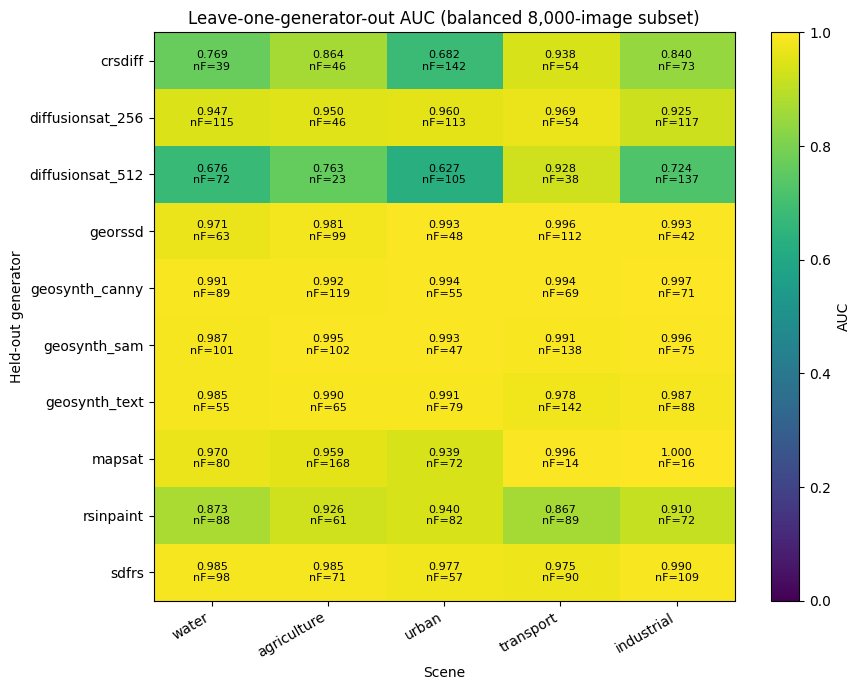

In [ ]:
# LOGO evaluation on the balanced 8,000-image subset.
# Keep the same real-image split for each holdout.
# Use held-out fake images from the balanced subset.
real_train = train_df[train_df.label_id.eq(0)].copy()
real_test = test_df[test_df.label_id.eq(0)].copy()
fake_all = bal[bal.label_id.eq(1)].copy()
GENS = sorted(fake_all.generator.dropna().unique())

print('LOGO evaluation source: principal balanced 8,000-image subset')
print('Balanced fake images available for LOGO:', len(fake_all))

# Cache includes confidence intervals and counts.
logo_path = f'{OUT}/logo_clean_results_with_ci.json'
results = json.load(open(logo_path)) if os.path.exists(logo_path) else {}

for g_idx, g in enumerate(GENS):
    # Reuse only compatible cached results.
    cached_ok = (
        g in results and
        all(isinstance(results[g].get(sc), dict) and 'n_fake' in results[g][sc]
            for sc in SCENES)
    )
    if cached_ok:
        print('skip cached:', g)
        continue

    print('\n=== hold out:', g, '===')
    tr = pd.concat([real_train, fake_all[~fake_all.generator.eq(g)]], ignore_index=True)
    te = pd.concat([real_test,  fake_all[fake_all.generator.eq(g)]], ignore_index=True)

    # Same seed for each holdout.
    seed_everything(SEED)
    m = make_resnet(SEED)
    m = train_model(m, tr, epochs=5, lr=1e-3, seed=SEED)
    pp = predict(m, te)

    overall_auc, overall_lo, overall_hi = auc_ci(
        pp.label, pp.prob_fake, B=B, seed=SEED + 5000 + g_idx
    )

    row = {
        'overall_auc': float(overall_auc),
        'overall_ci_low': float(overall_lo),
        'overall_ci_high': float(overall_hi),
        'n_test': int(len(pp)),
        'n_fake_test': int((pp.label == 1).sum()),
        'n_real_test': int((pp.label == 0).sum()),
        'evaluation_subset': 'principal_8000_balanced_subset'
    }

    for s_idx, sc in enumerate(SCENES):
        d = pp[pp.scene.eq(sc)].copy()
        n_fake = int((d.label == 1).sum())
        n_real = int((d.label == 0).sum())

        if d.label.nunique() == 2 and n_fake > 0 and n_real > 0:
            auc, lo, hi = auc_ci(
                d.label,
                d.prob_fake,
                B=B,
                seed=SEED + 6000 + 100 * g_idx + s_idx
            )
            cell = {
                'auc': float(auc),
                'ci_low': float(lo),
                'ci_high': float(hi),
                'n_fake': n_fake,
                'n_real': n_real,
                'n_total': int(len(d))
            }
        else:
            cell = {
                'auc': None,
                'ci_low': None,
                'ci_high': None,
                'n_fake': n_fake,
                'n_real': n_real,
                'n_total': int(len(d))
            }
        row[sc] = cell

    results[g] = row
    with open(logo_path, 'w') as f:
        json.dump(results, f, indent=2)
    print(row)

# Per-scene LOGO results.
logo_long = []
for g in GENS:
    r = results[g]
    for sc in SCENES:
        c = r[sc]
        logo_long.append({
            'held_out_generator': g,
            'scene': sc,
            'AUC': c['auc'],
            'CI_low': c['ci_low'],
            'CI_high': c['ci_high'],
            'n_fake': c['n_fake'],
            'n_real': c['n_real'],
            'n_total': c['n_total'],
            'evaluation_subset': r['evaluation_subset']
        })

logo_long = pd.DataFrame(logo_long)
display(logo_long)
logo_long.to_csv(f'{OUT}/logo_per_cell_results_with_ci_and_counts.csv', index=False)

# Matrices for the heatmap.
logo_auc = logo_long.pivot(index='held_out_generator', columns='scene', values='AUC').reindex(index=GENS, columns=SCENES)
logo_nfake = logo_long.pivot(index='held_out_generator', columns='scene', values='n_fake').reindex(index=GENS, columns=SCENES)
logo_ci_low = logo_long.pivot(index='held_out_generator', columns='scene', values='CI_low').reindex(index=GENS, columns=SCENES)
logo_ci_high = logo_long.pivot(index='held_out_generator', columns='scene', values='CI_high').reindex(index=GENS, columns=SCENES)

logo_auc.to_csv(f'{OUT}/logo_auc_matrix.csv')
logo_nfake.to_csv(f'{OUT}/logo_fake_counts_matrix.csv')
logo_ci_low.to_csv(f'{OUT}/logo_ci_low_matrix.csv')
logo_ci_high.to_csv(f'{OUT}/logo_ci_high_matrix.csv')

print('\nAUC matrix:')
display(logo_auc)
print('\nFake test counts underlying each AUC cell:')
display(logo_nfake)
print('\nIMPORTANT: the heatmap point estimates should be interpreted with their sample sizes and CIs;')
print('the displayed heatmap itself does not show uncertainty unless you explicitly annotate it.')

# Heatmap with AUC and fake-image count.
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(logo_auc.to_numpy(dtype=float), aspect='auto', vmin=0.0, vmax=1.0)
ax.set_xticks(np.arange(len(SCENES)))
ax.set_xticklabels(SCENES, rotation=30, ha='right')
ax.set_yticks(np.arange(len(GENS)))
ax.set_yticklabels(GENS)
ax.set_xlabel('Scene')
ax.set_ylabel('Held-out generator')
ax.set_title('Leave-one-generator-out AUC (balanced 8,000-image subset)')
for i, g in enumerate(GENS):
    for j, sc in enumerate(SCENES):
        a = logo_auc.loc[g, sc]
        n = int(logo_nfake.loc[g, sc])
        txt = 'NA' if pd.isna(a) else f'{a:.3f}\nnF={n}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='AUC')
plt.tight_layout()
plt.savefig(f'{OUT}/logo_auc_heatmap_with_fake_counts.png', dpi=220, bbox_inches='tight')
plt.show()


In [4]:
import json
import pandas as pd

with open(f'{OUT}/logo_clean_results_with_ci.json', 'r') as f:
    results = json.load(f)

logo_overall = pd.DataFrame([
    {
        'generator': g,
        'AUC': r['overall_auc'],
        'CI_low': r['overall_ci_low'],
        'CI_high': r['overall_ci_high'],
        'n_test': r['n_test'],
        'n_fake': r['n_fake_test'],
        'n_real': r['n_real_test']
    }
    for g, r in results.items()
]).sort_values('generator')

display(logo_overall)

print(
    'Overall LOGO AUC range:',
    logo_overall['AUC'].min(),
    'to',
    logo_overall['AUC'].max()
)

,generator,AUC,CI_low,CI_high,n_test,n_fake,n_real
0,crsdiff,0.775444,0.743639,0.806215,1184,354,830
1,diffusionsat_256,0.946057,0.932908,0.958176,1275,445,830
2,diffusionsat_512,0.695884,0.661171,0.729686,1205,375,830
3,georssd,0.988054,0.982896,0.992331,1194,364,830
4,geosynth_canny,0.993378,0.990417,0.996004,1233,403,830
5,geosynth_sam,0.991858,0.988817,0.994656,1293,463,830
6,geosynth_text,0.983868,0.977328,0.989230,1259,429,830
7,mapsat,0.962372,0.950923,0.973023,1180,350,830
8,rsinpaint,0.898562,0.877578,0.918071,1222,392,830
9,sdfrs,0.980629,0.974247,0.986377,1255,425,830


Overall LOGO AUC range: 0.6958843373493977 to 0.9933779784149002


## 11. FFT analysis


Shared FFT colour scale for Figures 4.2/4.3: vmin=4.709178, vmax=10.241908


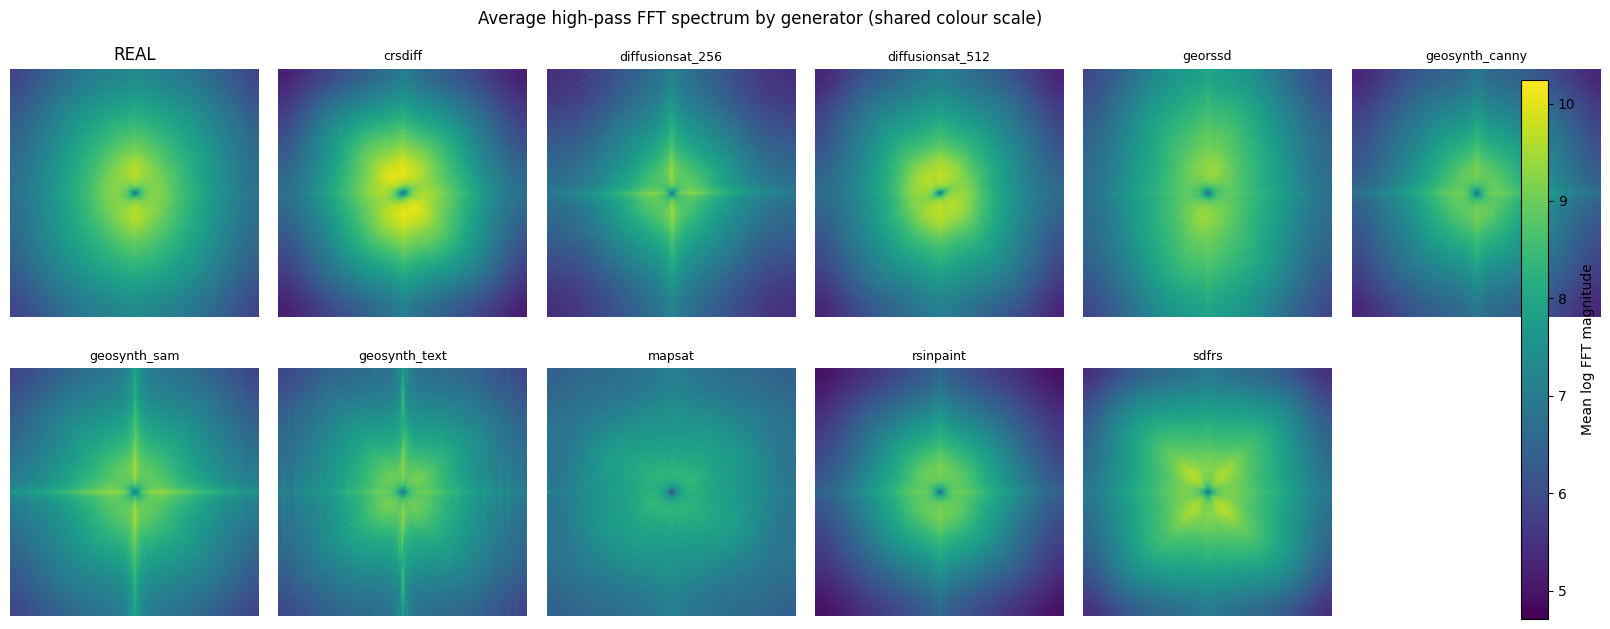

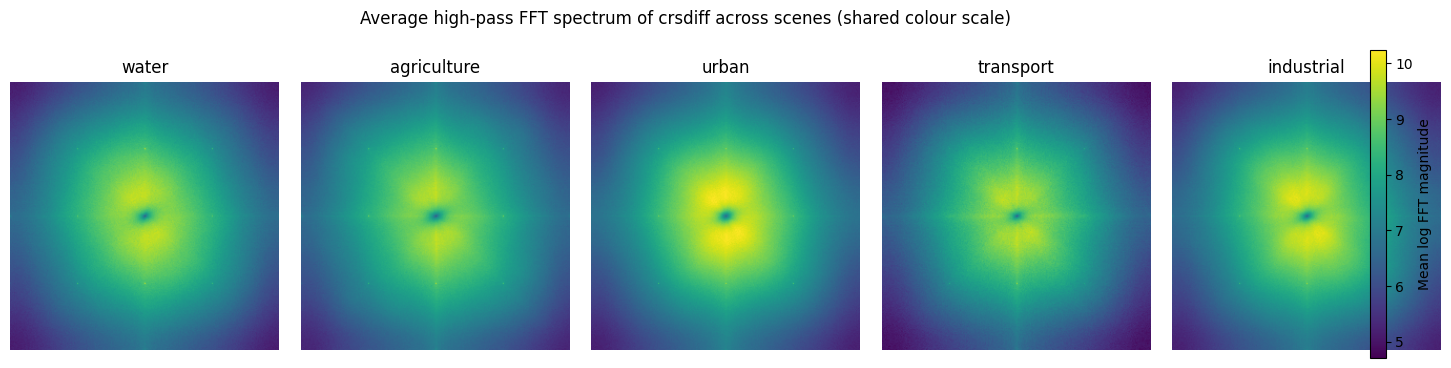

In [ ]:
def residual_spectrum(paths, size=256, max_imgs=300):
    acc = None
    n = 0
    for p in paths[:max_imgs]:
        try:
            img = Image.open(p).convert('L').resize((size, size))
            x = np.asarray(img, dtype=np.float32)
            blur = cv2.GaussianBlur(x, (0, 0), sigmaX=3)
            res = x - blur
            f = np.fft.fftshift(np.fft.fft2(res))
            mag = np.log1p(np.abs(f))
            acc = mag if acc is None else acc + mag
            n += 1
        except Exception:
            pass
    if n == 0:
        raise ValueError('No valid images were available for FFT averaging.')
    return acc / n

def sampled_paths(frame, n=300, seed=SEED):
    return frame.sample(n=min(n, len(frame)), random_state=seed)['path'].tolist()

# Use one shared colour scale for all FFT panels.
gens = sorted(df[df.label_id.eq(1)].generator.dropna().unique())
G = 'crsdiff' if 'crsdiff' in gens else gens[0]

spec_real = residual_spectrum(sampled_paths(df[df.label_id.eq(0)], 300, SEED))
generator_spectra = {}
for g in gens:
    generator_spectra[g] = residual_spectrum(
        sampled_paths(df[(df.label_id.eq(1)) & (df.generator.eq(g))], 300, SEED)
    )

scene_spectra = {}
for sc in SCENES:
    d = df[(df.label_id.eq(1)) & (df.generator.eq(G)) & (df.clip_scene.eq(sc))]
    scene_spectra[sc] = residual_spectrum(sampled_paths(d, 300, SEED))

all_fft_panels = [spec_real] + list(generator_spectra.values()) + list(scene_spectra.values())
global_vmin = min(float(np.nanmin(x)) for x in all_fft_panels)
global_vmax = max(float(np.nanmax(x)) for x in all_fft_panels)
print(f'Shared FFT colour scale for Figures 4.2/4.3: vmin={global_vmin:.6f}, vmax={global_vmax:.6f}')

# Average FFT spectrum by generator.
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
axes = axes.flatten()
last_im = axes[0].imshow(spec_real, cmap='viridis', vmin=global_vmin, vmax=global_vmax)
axes[0].set_title('REAL')
axes[0].axis('off')

for i, g in enumerate(gens):
    last_im = axes[i+1].imshow(
        generator_spectra[g], cmap='viridis', vmin=global_vmin, vmax=global_vmax
    )
    axes[i+1].set_title(g, fontsize=9)
    axes[i+1].axis('off')

for j in range(len(gens)+1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Average high-pass FFT spectrum by generator (shared colour scale)')
fig.colorbar(last_im, ax=axes.tolist(), fraction=0.025, pad=0.02, label='Mean log FFT magnitude')
plt.subplots_adjust(top=0.90, right=0.92, wspace=0.08, hspace=0.18)
plt.savefig(f'{OUT}/average_highpass_fft_by_generator.png', dpi=220, bbox_inches='tight')
plt.savefig(f'{OUT}/fft_by_generator.png', dpi=220, bbox_inches='tight')
plt.show()

# Compare one generator across scenes.
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
last_im = None
for i, sc in enumerate(SCENES):
    last_im = axes[i].imshow(
        scene_spectra[sc], cmap='viridis', vmin=global_vmin, vmax=global_vmax
    )
    axes[i].set_title(sc)
    axes[i].axis('off')

fig.suptitle(f'Average high-pass FFT spectrum of {G} across scenes (shared colour scale)')
fig.colorbar(last_im, ax=axes.tolist(), fraction=0.025, pad=0.02, label='Mean log FFT magnitude')
plt.subplots_adjust(top=0.82, right=0.92, wspace=0.08)
plt.savefig(f'{OUT}/average_highpass_fft_{G}_by_scene.png', dpi=220, bbox_inches='tight')
plt.savefig(f'{OUT}/fft_{G}_by_scene.png', dpi=220, bbox_inches='tight')
plt.show()

# Save the shared colour scale.
with open(f'{OUT}/fft_shared_colour_scale.json', 'w') as f:
    json.dump({'vmin': global_vmin, 'vmax': global_vmax, 'generator_for_scene_figure': G}, f, indent=2)


FFT spectra not found in memory — recomputing spectra only.


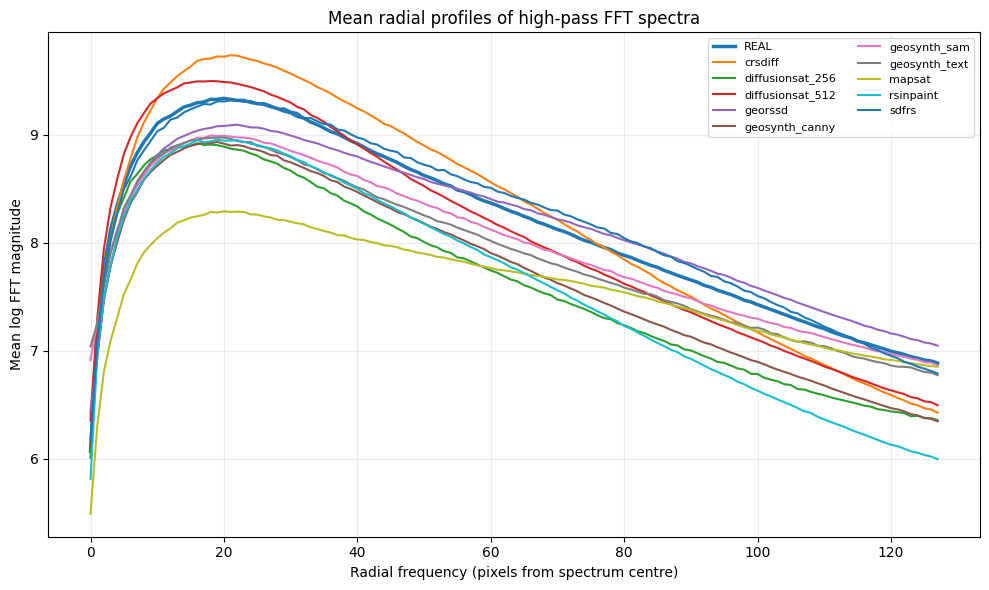

Saved Figure 4.4 to:
/content/drive/MyDrive/rsfake_clean_rerun/fft_radial.png


In [8]:
# Radial FFT profiles.

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

SEED = globals().get('SEED', 42)
OUT = globals().get(
    'OUT',
    '/content/drive/MyDrive/rsfake_clean_rerun'
)

# Check required data.
if 'df' not in globals():
    raise RuntimeError(
        "df is not available. Run the data-loading/setup cells first. "
        "You do NOT need to retrain any model."
    )

# FFT helper functions.
if 'residual_spectrum' not in globals():

    def residual_spectrum(paths, size=256, max_imgs=300):
        acc = None
        n = 0

        for p in paths[:max_imgs]:
            try:
                img = Image.open(p).convert('L').resize((size, size))
                x = np.asarray(img, dtype=np.float32)

                blur = cv2.GaussianBlur(
                    x,
                    (0, 0),
                    sigmaX=3
                )

                residual = x - blur

                fft = np.fft.fftshift(
                    np.fft.fft2(residual)
                )

                magnitude = np.log1p(
                    np.abs(fft)
                )

                acc = (
                    magnitude
                    if acc is None
                    else acc + magnitude
                )

                n += 1

            except Exception:
                pass

        if n == 0:
            raise ValueError(
                'No valid images were available for FFT averaging.'
            )

        return acc / n


if 'sampled_paths' not in globals():

    def sampled_paths(frame, n=300, seed=SEED):
        return frame.sample(
            n=min(n, len(frame)),
            random_state=seed
        )['path'].tolist()


# Compute average spectra if needed.
if (
    'spec_real' not in globals()
    or 'generator_spectra' not in globals()
):

    print(
        'FFT spectra not found in memory — recomputing spectra only.'
    )

    spec_real = residual_spectrum(
        sampled_paths(
            df[df.label_id.eq(0)],
            300,
            SEED
        )
    )

    gens = sorted(
        df[df.label_id.eq(1)]
        .generator
        .dropna()
        .unique()
    )

    generator_spectra = {}

    for g in gens:

        generator_spectra[g] = residual_spectrum(
            sampled_paths(
                df[
                    (df.label_id.eq(1))
                    & (df.generator.eq(g))
                ],
                300,
                SEED
            )
        )

else:

    gens = sorted(generator_spectra.keys())


# Radial profile.
def radial_profile(spectrum):

    h, w = spectrum.shape

    y, x = np.indices((h, w))

    cy = h // 2
    cx = w // 2

    radius = np.sqrt(
        (x - cx) ** 2
        + (y - cy) ** 2
    ).astype(int)

    radial_sum = np.bincount(
        radius.ravel(),
        weights=spectrum.ravel()
    )

    radial_count = np.bincount(
        radius.ravel()
    )

    profile = radial_sum / np.maximum(
        radial_count,
        1
    )

    # Keep radii to the Nyquist distance.
    max_radius = min(h, w) // 2

    return (
        np.arange(max_radius),
        profile[:max_radius]
    )


# Radial FFT profiles.
plt.figure(figsize=(10, 6))

r_real, p_real = radial_profile(spec_real)

plt.plot(
    r_real,
    p_real,
    linewidth=2.5,
    label='REAL'
)

for g in gens:

    r, p = radial_profile(
        generator_spectra[g]
    )

    plt.plot(
        r,
        p,
        linewidth=1.5,
        label=g
    )


plt.xlabel(
    'Radial frequency (pixels from spectrum centre)'
)

plt.ylabel(
    'Mean log FFT magnitude'
)

plt.title(
    'Mean radial profiles of high-pass FFT spectra'
)

plt.legend(
    fontsize=8,
    ncol=2
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


# Save figure.
save_path = f'{OUT}/fft_radial.png'

plt.savefig(
    save_path,
    dpi=220,
    bbox_inches='tight'
)

plt.show()

print('Saved Figure 4.4 to:')
print(save_path)

## 12. Grad-CAM

Grad-CAM targets the fake class using test images from the main ResNet-50 model.


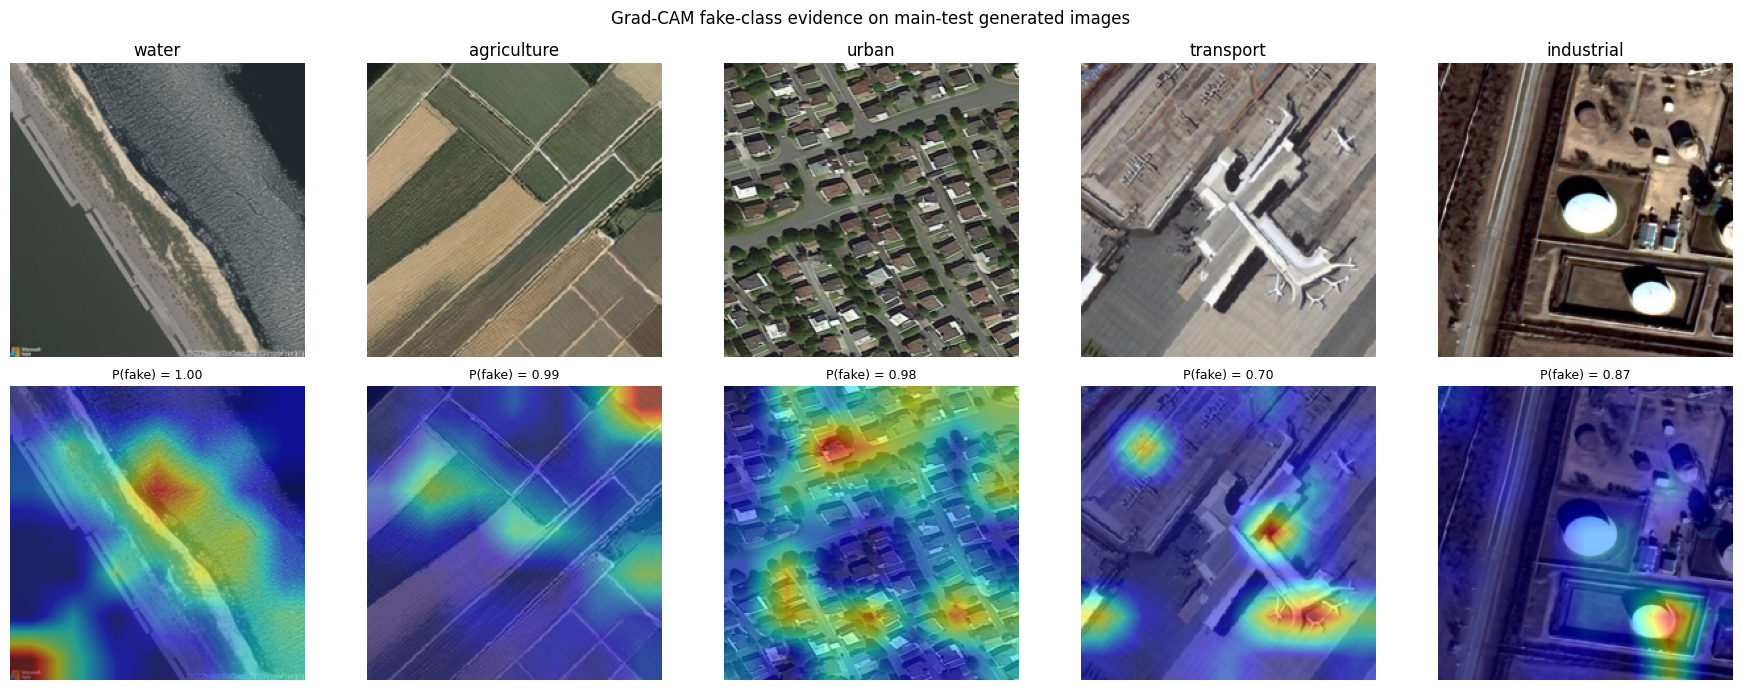

Saved: /content/drive/MyDrive/rsfake_clean_rerun/gradcam_main_model.png


In [ ]:
# Add RemoteCLIP confidence.
conf_map = df.set_index('path')['confidence'].to_dict()

main_test = test_df.copy()
main_test['confidence'] = main_test.path.map(conf_map)

# Select one fake test image per scene.
chosen = {}

for sc in SCENES:
    d = main_test[
        (main_test.clip_scene.eq(sc)) &
        (main_test.label_id.eq(1))
    ].sort_values('confidence', ascending=False)

    if len(d) == 0:
        raise ValueError(f'No fake test image for {sc}')

    chosen[sc] = d.iloc[0]['path']

# Grad-CAM hooks.

feats = {}
grads = {}

def f_hook(module, inputs, output):
    feats['v'] = output.detach()

def b_hook(module, grad_input, grad_output):
    if grad_output[0] is not None:
        grads['v'] = grad_output[0].detach()

h1 = resnet.layer4.register_forward_hook(f_hook)
h2 = resnet.layer4.register_full_backward_hook(b_hook)

# Grad-CAM function.

def gradcam_fake_class(path):

    resnet.eval()

    img = Image.open(path).convert('RGB')

    x = transform(img).unsqueeze(0).to(device)

    # Enable input gradients for Grad-CAM.
    x.requires_grad_(True)

    # Clear previous values.
    feats.clear()
    grads.clear()

    # Forward pass.
    out = resnet(x)

    prob = torch.softmax(out, dim=1)[0, 1].item()

    # Clear gradients.
    resnet.zero_grad(set_to_none=True)

    # Backpropagate from the fake class.
    out[0, 1].backward()

    # Checks.
    if 'v' not in feats:
        raise RuntimeError(
            'Grad-CAM forward activations were not captured from layer4.'
        )

    if 'v' not in grads:
        raise RuntimeError(
            'Grad-CAM gradients were not captured from layer4.'
        )

    # Pool gradients.
    weights = grads['v'].mean(
        dim=(2, 3),
        keepdim=True
    )

    # Weighted activation map.
    cam = torch.relu(
        (weights * feats['v']).sum(dim=1)
    )

    cam = cam.squeeze().detach().cpu().numpy()

    # Normalise.
    cam_min = cam.min()
    cam_max = cam.max()

    cam = (cam - cam_min) / (
        cam_max - cam_min + 1e-8
    )

    # Resize CAM.
    cam = cv2.resize(
        cam,
        (224, 224),
        interpolation=cv2.INTER_LINEAR
    )

    base = np.asarray(
        img.resize((224, 224))
    )

    return base, cam, prob

# Generate figure.

fig, axes = plt.subplots(
    2,
    len(SCENES),
    figsize=(18, 7)
)

for i, sc in enumerate(SCENES):

    base, cam, p = gradcam_fake_class(
        chosen[sc]
    )

    # Original image.
    axes[0, i].imshow(base)
    axes[0, i].set_title(sc)
    axes[0, i].axis('off')

    # Grad-CAM overlay.
    axes[1, i].imshow(base)
    axes[1, i].imshow(
        cam,
        cmap='jet',
        alpha=0.5,
        vmin=0,
        vmax=1
    )

    axes[1, i].set_title(
        f'P(fake) = {p:.2f}',
        fontsize=9
    )

    axes[1, i].axis('off')

plt.suptitle(
    'Grad-CAM fake-class evidence on main-test generated images'
)

plt.tight_layout()

plt.savefig(
    f'{OUT}/gradcam_main_model.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# Remove hooks.
h1.remove()
h2.remove()

print('Saved:', f'{OUT}/gradcam_main_model.png')


## 13. Final checks


In [ ]:
summary = {
    'canonical_real_locations': int(
        df[df.label_id.eq(0)].location.nunique()
    ),
    'balanced_images': int(len(bal)),
    'main_train_n': int(len(train_df)),
    'main_test_n': int(len(test_df)),
    'main_accuracy': float(
        accuracy_score(pred.label, pred.pred)
    ),
    'main_auc': float(
        roc_auc_score(pred.label, pred.prob_fake)
    ),
    'vit_accuracy': float(
        accuracy_score(vit_pred.label, vit_pred.pred)
    ),
    'vit_auc': float(
        roc_auc_score(vit_pred.label, vit_pred.prob_fake)
    ),
    'real_location_leakage': int(len(leak)),
    'logo_evaluation_subset': 'principal_8000_balanced_subset',
    'logo_cell_uncertainty': (
        '2000-resample image-level bootstrap 95% CI'
    ),
    'logo_cell_counts_reported': True,
    'fft_panels_shared_colour_scale': True,
}

print(json.dumps(summary, indent=2))

with open(f'{OUT}/FINAL_SUMMARY.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\nFiles saved under:', OUT)


{
  "canonical_real_locations": 15861,
  "balanced_images": 8000,
  "main_train_n": 6392,
  "main_test_n": 1608,
  "main_accuracy": 0.9210199004975125,
  "main_auc": 0.9761142255396908,
  "vit_accuracy": 0.9197761194029851,
  "vit_auc": 0.9683479418961192,
  "real_location_leakage": 0,
  "logo_evaluation_subset": "principal_8000_balanced_subset",
  "logo_cell_uncertainty": "2000-resample image-level bootstrap 95% CI",
  "logo_cell_counts_reported": true,
  "fft_panels_shared_colour_scale": true
}

Files saved under: /content/drive/MyDrive/rsfake_clean_rerun
